In [133]:
%md
# Analyse NTP logs
# Michael Camilleri
# May 2025

# Read the NTP logs and perform analysis and make offsets available

# loopstats


UsageError: Line magic function `%md` not found.


# Analyse NTP logs
Michael Camilleri
May 2025

Read the NTP logs and perform analysis and make offsets available

## loopstats
Read all loopstats files from the /etc folder. Resample at minute intervals with limited interpolation and output to a master Excel file with the 1 minute regular time series of offset and frequency


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime as dt
from datetime import time, timedelta
import os
import scipy

# Use the cleaned ntp_analysis.py functions
from gps_timing_analysis.python.ntp_analysis import mjd_to_date, process_loopstats, visualize_performance, generate_regular_timeseries

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [3]:
#pip install seaborn

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_theme()

In [4]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [140]:
file_path = 'C:/NTP/etc/'
file_path_output = 'C:\\Users\\admin\\Occultations\\'
files = os.listdir(file_path)
files = [s for s in files if "loopstats" in s and '.2025' in s]

In [249]:
# Process all Loopstats log files

rts_dict ={}
for i in files:
    print(i,end=', ')
    df = process_loopstats(file_path + i)
    #visualize_performance(df)
    offset_rts = generate_regular_timeseries(df.copy(), 'Offset','1min') *1000
    freq_rts = generate_regular_timeseries(df.copy(), 'Frequency','1min')
    jitter_rts = generate_regular_timeseries(df.copy(), 'Jitter','1min') *1000
    stability_rts = generate_regular_timeseries(df.copy(), 'Stability','1min')
    interval_rts = generate_regular_timeseries(df.copy(), 'Interval','1min')

    rts = pd.merge(pd.DataFrame(offset_rts,columns=['Offset']),pd.DataFrame(freq_rts,columns=['Frequency']),on='Timestamp')
    rts = pd.merge(rts,pd.DataFrame(jitter_rts,columns=['Jitter']),on='Timestamp')
    rts = pd.merge(rts,pd.DataFrame(stability_rts,columns=['Allan Deviation']),on='Timestamp')
    rts = pd.merge(rts,pd.DataFrame(interval_rts,columns=['Interval']),on='Timestamp')

    rts_dict[i] = rts.reset_index()

all_loopstats_rts=pd.concat(rts_dict).reset_index()[['Timestamp','Offset','Frequency','Jitter','Allan Deviation','Interval']]

# Generate regular time series for entire span 
regular_ts = all_loopstats_rts.copy()
all_loopstats_rts = pd.DataFrame(pd.date_range(start=regular_ts['Timestamp'].min(),end=regular_ts['Timestamp'].max(),freq='1min').values , columns = ['Timestamp'])
all_loopstats_rts = pd.merge(all_loopstats_rts,regular_ts, on='Timestamp',how='left')
all_loopstats_rts['Timestamp'].diff().unique()

all_loopstats_rts.head()
all_loopstats_rts.tail()
all_loopstats_rts.to_excel(file_path_output+"loopstats.xlsx",index=False)



loopstats.20250101, loopstats.20250102, loopstats.20250104, loopstats.20250105, loopstats.20250119, loopstats.20250123, loopstats.20250129, loopstats.20250130, loopstats.20250131, loopstats.20250201, loopstats.20250204, loopstats.20250205, loopstats.20250206, loopstats.20250207, loopstats.20250208, loopstats.20250211, loopstats.20250214, loopstats.20250215, loopstats.20250216, loopstats.20250217, loopstats.20250218, loopstats.20250219, loopstats.20250221, loopstats.20250223, loopstats.20250224, loopstats.20250225, loopstats.20250226, loopstats.20250227, loopstats.20250228, loopstats.20250302, loopstats.20250303, loopstats.20250304, loopstats.20250305, loopstats.20250306, loopstats.20250307, loopstats.20250308, loopstats.20250309, loopstats.20250310, loopstats.20250311, loopstats.20250312, loopstats.20250313, loopstats.20250314, loopstats.20250315, loopstats.20250316, loopstats.20250320, loopstats.20250321, loopstats.20250323, loopstats.20250326, loopstats.20250327, loopstats.20250328, 

<TimedeltaArray>
[NaT, '0 days 00:01:00']
Length: 2, dtype: timedelta64[ns]

,Timestamp,Offset,Frequency,Jitter,Allan Deviation,Interval
0,2025-01-01 00:04:00,0.0,428.955,0.000477,0.226777,6.0
1,2025-01-01 00:05:00,0.0,428.955,0.000477,0.226777,6.0
2,2025-01-01 00:06:00,0.0,428.955,0.000477,0.226777,6.0
3,2025-01-01 00:07:00,0.0,428.955,0.000477,0.226777,6.0
4,2025-01-01 00:08:00,0.0,428.955,0.000477,0.226777,6.0


,Timestamp,Offset,Frequency,Jitter,Allan Deviation,Interval
207346,2025-05-24 23:50:00,5.768209,-15.692,0.451350,0.107301,6.0
207347,2025-05-24 23:51:00,5.768209,-15.692,0.451350,0.107301,6.0
207348,2025-05-24 23:52:00,5.768209,-15.692,0.451350,0.107301,6.0
207349,2025-05-24 23:53:00,5.768209,-15.692,0.451350,0.107301,6.0
207350,2025-05-24 23:54:00,5.560432,-15.605,0.428542,0.104927,6.0


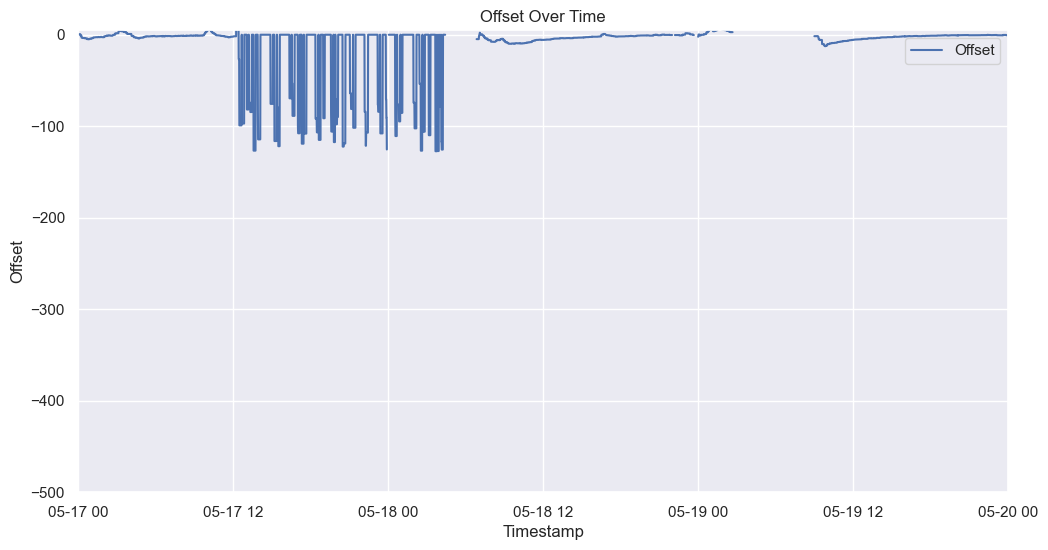

In [254]:
visualize_performance(all_loopstats_rts,'Offset',[datetime(2025,5,17),datetime(2025,5,20)],ylim=[-500,5])



In [20]:
files = os.listdir(file_path)
files = [s for s in files if "peerstats" in s and '.20' in s]
files

['peerstats.20250523']

In [22]:
allntp.plot('Time Rounded','Offset (ms)')
#allntp['Offset (ms)'].hist()

AttributeError: 'dict' object has no attribute 'plot'

<Axes: xlabel='Time Rounded'>

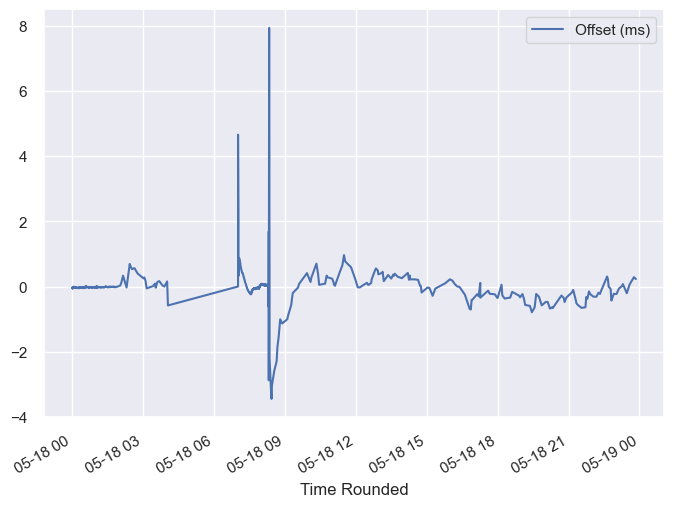

In [12]:
timecheck = (dt.strptime("20250518",'%Y%m%d'))

sameday = allntp[allntp.Date ==timecheck]
sameday.plot('Time Rounded','Offset (ms)')

mins = [timecheck + timedelta(seconds = i) for i in range(0,86440,60)]
allday = pd.DataFrame(mins,columns =['Minutes'])
allday = pd.merge(allday,sameday,left_on='Minutes',right_on ='Time Rounded',how='left')

In [13]:
allday.set_index('Minutes')
allday.interpolate(method='linear',inplace=True)

,Date,Time,Offset (ms),Frequency (ppm),Jitter,PPS Jitter,Stations,Time Rounded,Source file
Minutes,,,,,,,,,
2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:05.564,-0.044877,21.824,0.000006,0.001374,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:13.554,-0.051454,21.822,0.000006,0.001400,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:21.554,-0.041139,21.821,0.000007,0.001383,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:29.551,-0.055132,21.819,0.000008,0.001423,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2025-05-18 00:01:00,2025-05-18,2025-05-18 00:00:37.558,-0.050999,21.817,0.000008,0.001441,3.0,2025-05-18 00:01:00,C:\Users\admin\Occultations\20250518 NTP tests...
...,...,...,...,...,...,...,...,...,...
2025-05-18 23:56:00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2025-05-18 23:57:00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2025-05-18 23:58:00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN


In [14]:
allday.head()
allday.tail()

,Minutes,Date,Time,Offset (ms),Frequency (ppm),Jitter,PPS Jitter,Stations,Time Rounded,Source file
0,2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:05.564,-0.044877,21.824,0.000006,0.001374,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
1,2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:13.554,-0.051454,21.822,0.000006,0.001400,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2,2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:21.554,-0.041139,21.821,0.000007,0.001383,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
3,2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:29.551,-0.055132,21.819,0.000008,0.001423,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
4,2025-05-18 00:01:00,2025-05-18,2025-05-18 00:00:37.558,-0.050999,21.817,0.000008,0.001441,3.0,2025-05-18 00:01:00,C:\Users\admin\Occultations\20250518 NTP tests...


,Minutes,Date,Time,Offset (ms),Frequency (ppm),Jitter,PPS Jitter,Stations,Time Rounded,Source file
1960,2025-05-18 23:56:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN
1961,2025-05-18 23:57:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN
1962,2025-05-18 23:58:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN
1963,2025-05-18 23:59:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN
1964,2025-05-19 00:00:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN


In [15]:
allday.shape

(1965, 10)

<Axes: title={'center': 'NTP Offset'}, xlabel='MM-DD Hour'>

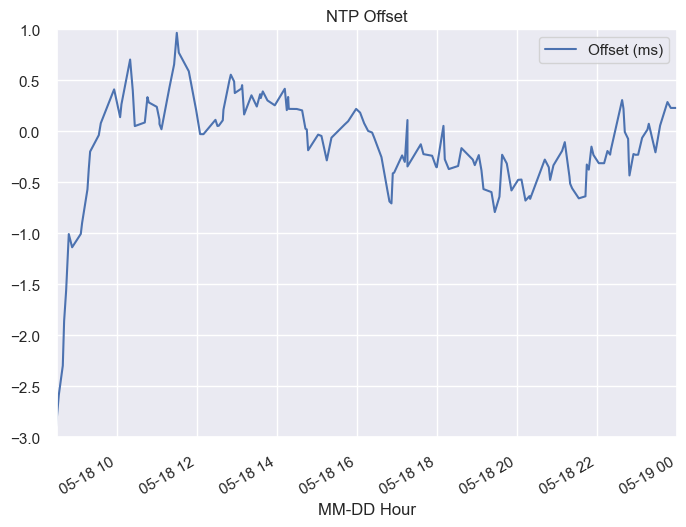

In [38]:
allday.plot('Minutes','Offset (ms)',xlim=[dt.strptime("20250518 08:30:00",'%Y%m%d %H:%M:%S'),dt.strptime("20250519",'%Y%m%d')],ylim=[-3,1],title="NTP Offset",xlabel='MM-DD Hour')

In [17]:
import pickle
ff = open('ntp_offsets','wb')
pickle.dump(allday,ff)
ff.close()

In [141]:
pd.read_csv(r'C:\Program Files (x86)\VisualGPS\NMEATime2\gpslog.txt',delimiter='\t')

,"$GNGGA,060318.000,3650.1263,S,17439.4673,E,2,39,0.42,26.8,M,26.4,M,,*58"
0,"$GNGSA,A,3,04,09,16,27,08,07,194,26,03,31,,,0...."
1,"$GNGSA,A,3,71,73,74,72,80,82,,,,,,,0.77,0.42,0..."
2,"$GNGSA,A,3,07,27,30,08,21,,,,,,,,0.77,0.42,0.6..."
3,"$GNGSA,A,3,37,20,32,04,23,01,59,39,08,13,16,38..."
4,"$GNGSA,A,3,46,43,06,28,19,11,,,,,,,0.77,0.42,0..."
...,...
61711,"$GNGSA,A,3,72,73,,,,,,,,,,,0.96,0.47,0.84,2*03"
61712,"$GNGSA,A,3,27,21,19,15,07,30,,,,,,,0.96,0.47,0..."
61713,"$GNGSA,A,3,46,37,28,39,27,16,59,06,19,20,09,30..."
61714,"$GNGSA,A,3,23,,,,,,,,,,,,0.96,0.47,0.84,4*05"
